In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import pulp
except ImportError:
    pulp = None
    print("PuLP not installed. Run: pip install pulp")

plt.style.use("default")

In [7]:
DATA_PATH = r"C:\Users\NTC\Desktop\dataset_clean.csv"  
OUT_DIR = r"C:\Users\NTC\Desktop\OUT_DIR1"
Path(OUT_DIR).mkdir(exist_ok=True)


BATTERY_CAPACITY_KWH   = 10.0   
INITIAL_SOC_FRACTION   = 0.5    
MIN_SOC_FRACTION       = 0.10   
MAX_SOC_FRACTION       = 0.95   
MAX_CHARGE_KW          = 3.0   
MAX_DISCHARGE_KW       = 3.0    


ROUND_TRIP_EFFICIENCY  = 0.9
ETA_CH = ETA_DIS = np.sqrt(ROUND_TRIP_EFFICIENCY)  

EXPORT_PRICE_JOD_PER_KWH = 0.0

PRICE_LOW_THRESHOLD  = 0.06   
PRICE_HIGH_THRESHOLD = 0.13   

In [9]:
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Dataset not found at: {DATA_PATH}")

df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

print("Columns:", df.columns.tolist())
print("Rows:", len(df))


def find_col(df, keywords):
    
    for k in keywords:
        for c in df.columns:
            if k.lower() in c.lower():
                return c
    return None


pv_col        = find_col(df, ["pv_kwh", "pv", "solar"])
wind_col      = find_col(df, ["wind_kwh", "wind"])
load_col      = find_col(df, ["load_kwh", "load", "demand"])
grid_imp_col  = find_col(df, ["grid_import_est_kWh", "grid_import"])
net_cost_col  = find_col(df, ["net_cost_JOD_est", "net_cost"])

print("Detected columns:")
print(" pv_col      =", pv_col)
print(" wind_col    =", wind_col)
print(" load_col    =", load_col)
print(" grid_imp_col=", grid_imp_col)
print(" net_cost_col=", net_cost_col)

required_cols = [pv_col, wind_col, load_col]
if any(c is None for c in required_cols):
    raise ValueError("Please check column detection and set pv_col, wind_col, load_col manually!")


pv   = df[pv_col].astype(float).fillna(0.0).values
wind = df[wind_col].astype(float).fillna(0.0).values
load = df[load_col].astype(float).fillna(0.0).values


Columns: ['timestamp', 'hour', 'dayofweek', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'temp_C', 'wind_speed_m_s', 'wind_dir_deg', 'GHI_W_m2', 'pv_kWh', 'wind_kW', 'wind_kWh', 'load_kWh', 'tariff_JOD_per_kWh', 'export_tariff_JOD_per_kWh', 'battery_capacity_kWh', 'battery_roundtrip_efficiency', 'pv_system_kWp', 'inverter_limit_kW', 'wind_speed_hub_m_s', 'air_density_kg_m3', 'pv_kW_est', 'battery_charge_power_kW', 'battery_discharge_power_kW', 'battery_degradation_cost_JOD_per_kWh_throughput', 'grid_import_limit_kW', 'grid_export_limit_kW', 'tariff_fils_per_kWh_raw', 'hybrid_gen_kWh', 'net_balance_kWh', 'grid_import_est_kWh', 'grid_export_est_kWh', 'energy_cost_JOD_est', 'export_revenue_JOD_est', 'net_cost_JOD_est', 'renewable_fraction', 'is_peak_18_22', 'day_of_year']
Rows: 17547
Detected columns:
 pv_col      = pv_kWh
 wind_col    = wind_kWh
 load_col    = load_kWh
 grid_imp_col= grid_import_est_kWh
 net_cost_col= net_cost_JOD_est


In [11]:

tariff_col = find_col(df, ["tariff", "price_per_kWh", "tariff_jod"])
if tariff_col is not None:
    print("Using existing tariff column:", tariff_col)
    tariff = df[tariff_col].astype(float).fillna(method="ffill").values
else:
    
    if grid_imp_col is not None and net_cost_col is not None:
        grid_imp = df[grid_imp_col].astype(float).fillna(0.0).values
        net_cost = df[net_cost_col].astype(float).fillna(0.0).values

        tariff = np.zeros(len(df))
        mask = grid_imp > 1e-6
        tariff[mask] = net_cost[mask] / grid_imp[mask]
        avg_price = tariff[mask].mean() if mask.any() else 0.1
        tariff[~mask] = avg_price
        print("Estimated tariff from net_cost/grid_import, avg:", avg_price)
    else:
      
        tariff = np.full(len(df), 0.1)
        print("No tariff/net_cost found → using constant 0.1 JOD/kWh")

print("Tariff stats (JOD/kWh):")
print(pd.Series(tariff).describe())


avg_tariff = float(pd.Series(tariff).mean())
base_loss_cost = avg_tariff * (1 - ROUND_TRIP_EFFICIENCY)
CYCLE_PENALTY_JOD_PER_KWH = 1.5 * base_loss_cost  

print("avg_tariff =", avg_tariff)
print("base_loss_cost =", base_loss_cost)
print("CYCLE_PENALTY_JOD_PER_KWH =", CYCLE_PENALTY_JOD_PER_KWH)


Using existing tariff column: tariff_JOD_per_kWh
Tariff stats (JOD/kWh):
count    17547.000000
mean         0.133249
std          0.022859
min          0.107000
25%          0.110000
50%          0.133000
75%          0.158000
max          0.176000
dtype: float64
avg_tariff = 0.13324944434946145
base_loss_cost = 0.013324944434946142
CYCLE_PENALTY_JOD_PER_KWH = 0.019987416652419213


C:\Users\NTC\AppData\Local\Temp\ipykernel_11772\3505255698.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  tariff = df[tariff_col].astype(float).fillna(method="ffill").values


In [13]:
def estimate_full_cycles_from_charged(charged_series, capacity_kwh):
    
    return charged_series.sum() / capacity_kwh

In [15]:
def run_rule_based(df, pv, wind, load, tariff,
                   battery_capacity=BATTERY_CAPACITY_KWH,
                   max_power=MAX_CHARGE_KW,
                   initial_soc_frac=INITIAL_SOC_FRACTION):
    
    n = len(df)
    soc_kwh = initial_soc_frac * battery_capacity
    min_soc_kwh = MIN_SOC_FRACTION * battery_capacity
    max_soc_kwh = MAX_SOC_FRACTION * battery_capacity
    max_charge_ac    = max_power * 1.0      
    max_discharge_ac = max_power * 1.0       

    soc_series       = np.zeros(n)
    charge_series    = np.zeros(n)   
    discharge_series = np.zeros(n)   
    grid_import      = np.zeros(n)
    grid_export      = np.zeros(n)
    cost             = np.zeros(n)

    for t in range(n):
        pv_t   = pv[t]
        wind_t = wind[t]
        load_t = load[t]
        price_t = float(tariff[t])

        renewable = max(0.0, pv_t) + max(0.0, wind_t)
        remaining_load = load_t

       
        used_from_renewable = min(renewable, remaining_load)
        remaining_load -= used_from_renewable
        renewable      -= used_from_renewable

        charge_ac    = 0.0
        discharge_ac = 0.0
        grid_imp     = 0.0
        grid_exp     = 0.0

        
        if price_t <= PRICE_LOW_THRESHOLD:
            space_kwh = max_soc_kwh - soc_kwh  
           
            max_charge_by_soc = space_kwh / ETA_CH if ETA_CH > 0 else 0.0
            to_charge_ac = min(max_charge_ac, max_charge_by_soc)
            if to_charge_ac > 1e-9:
                charge_ac += to_charge_ac
                soc_kwh   += ETA_CH * to_charge_ac
                grid_imp  += to_charge_ac

       
        if remaining_load > 1e-9 and soc_kwh > min_soc_kwh + 1e-9:
            
            max_deliverable_ac = (soc_kwh - min_soc_kwh) * ETA_DIS
            avail_ac = min(max_discharge_ac, max_deliverable_ac)
            to_discharge_ac = min(avail_ac, remaining_load)
            if to_discharge_ac > 1e-9:
                discharge_ac += to_discharge_ac
                soc_kwh      -= to_discharge_ac / ETA_DIS
                remaining_load -= to_discharge_ac

       
        if price_t >= PRICE_HIGH_THRESHOLD and remaining_load > 1e-9 and soc_kwh > min_soc_kwh + 1e-9:
            max_deliverable_ac = (soc_kwh - min_soc_kwh) * ETA_DIS
            avail_ac = min(max_discharge_ac - discharge_ac, max_deliverable_ac)
            extra_ac = min(avail_ac, remaining_load)
            if extra_ac > 1e-9:
                discharge_ac += extra_ac
                soc_kwh      -= extra_ac / ETA_DIS
                remaining_load -= extra_ac

       
        if remaining_load > 1e-9:
            grid_imp += remaining_load
            remaining_load = 0.0

       
        if renewable > 1e-9:
            space_kwh = max_soc_kwh - soc_kwh
            max_charge_by_soc = space_kwh / ETA_CH if ETA_CH > 0 else 0.0
            from_renew_ac = min(max_charge_ac - charge_ac, max_charge_by_soc, renewable)
            if from_renew_ac > 1e-9:
                charge_ac += from_renew_ac
                soc_kwh   += ETA_CH * from_renew_ac
                renewable -= from_renew_ac
            if renewable > 1e-9:
                grid_exp += renewable

     
        soc_kwh = min(max_soc_kwh, max(min_soc_kwh, soc_kwh))

        cost_t = grid_imp * price_t - grid_exp * EXPORT_PRICE_JOD_PER_KWH

        soc_series[t]       = soc_kwh
        charge_series[t]    = charge_ac
        discharge_series[t] = discharge_ac
        grid_import[t]      = grid_imp
        grid_export[t]      = grid_exp
        cost[t]             = cost_t

    results = pd.DataFrame({
        "timestamp": df["timestamp"],
        "pv_kWh": pv,
        "wind_kWh": wind,
        "load_kWh": load,
        "charge_kWh": charge_series,       
        "discharge_kWh": discharge_series,  
        "soc_kWh": soc_series,
        "grid_import_kWh": grid_import,
        "grid_export_kWh": grid_export,
        "tariff_JOD_per_kWh": tariff,
        "cost_JOD": cost,
    })
    results["cumulative_cost_JOD"] = results["cost_JOD"].cumsum()
    results["total_cost_JOD"] = results["cost_JOD"].sum()
    results["total_charged_kWh"] = results["charge_kWh"].sum()
    results["equivalent_full_cycles"] = estimate_full_cycles_from_charged(
        results["charge_kWh"], battery_capacity
    )
    return results


In [17]:
rb_results = run_rule_based(
    df, pv, wind, load, tariff,
    battery_capacity=BATTERY_CAPACITY_KWH,
    max_power=MAX_CHARGE_KW,
    initial_soc_frac=INITIAL_SOC_FRACTION
)

rb_out_path = os.path.join(OUT_DIR, "rule_based_results_eff09.csv")
rb_results.to_csv(rb_out_path, index=False)
print("Rule-Based results saved to:", rb_out_path)
print("Rule-Based total cost (JOD):", rb_results["cost_JOD"].sum())
print("Rule-Based equivalent full cycles:", rb_results["equivalent_full_cycles"].iloc[-1])

Rule-Based results saved to: C:\Users\NTC\Desktop\OUT_DIR1\rule_based_results_eff09.csv
Rule-Based total cost (JOD): 624.9029923927545
Rule-Based equivalent full cycles: 615.9116430097965


In [19]:
def run_optimization(df, pv, wind, load, tariff,
                     battery_capacity=BATTERY_CAPACITY_KWH,
                     max_charge=MAX_CHARGE_KW,
                     max_discharge=MAX_DISCHARGE_KW,
                     initial_soc_frac=INITIAL_SOC_FRACTION,
                     min_soc_frac=MIN_SOC_FRACTION,
                     max_soc_frac=MAX_SOC_FRACTION,
                     eta_ch=ETA_CH, eta_dis=ETA_DIS):
    if pulp is None:
        raise RuntimeError("PuLP not installed. Run: pip install pulp")

    n = len(df)
    idx = list(range(n))

    initial_soc = initial_soc_frac * battery_capacity
    min_soc     = min_soc_frac * battery_capacity
    max_soc     = max_soc_frac * battery_capacity

    prob = pulp.LpProblem("Battery_Scheduling_Optimization_Eff09", pulp.LpMinimize)

    
    grid_import   = pulp.LpVariable.dicts("grid_import", idx, lowBound=0, cat="Continuous")
    grid_export   = pulp.LpVariable.dicts("grid_export", idx, lowBound=0, cat="Continuous")
    charge_in     = pulp.LpVariable.dicts("charge_in", idx, lowBound=0, upBound=max_charge, cat="Continuous")
    discharge_out = pulp.LpVariable.dicts("discharge_out", idx, lowBound=0, upBound=max_discharge, cat="Continuous")
    soc           = pulp.LpVariable.dicts("soc", range(n+1), lowBound=min_soc, upBound=max_soc, cat="Continuous")

    
    prob += (
        pulp.lpSum([grid_import[t] * float(tariff[t]) for t in idx]) +
        CYCLE_PENALTY_JOD_PER_KWH * pulp.lpSum([charge_in[t] + discharge_out[t] for t in idx]) -
        EXPORT_PRICE_JOD_PER_KWH * pulp.lpSum([grid_export[t] for t in idx])
    )

 
    prob += soc[0] == initial_soc

    for t in idx:
        
        prob += (
            float(pv[t]) + float(wind[t]) + grid_import[t] + discharge_out[t]
            ==
            float(load[t]) + charge_in[t] + grid_export[t]
        )

        
        prob += (
            soc[t+1] ==
            soc[t] + eta_ch * charge_in[t] - (1.0 / eta_dis) * discharge_out[t]
        )

    
    solver = pulp.PULP_CBC_CMD(msg=False, timeLimit=180)
    result_status = prob.solve(solver)
    status = pulp.LpStatus[result_status]
    print("Optimization status:", status)

    grid_import_vals = np.array([pulp.value(grid_import[t])   for t in idx], dtype=float)
    grid_export_vals = np.array([pulp.value(grid_export[t])   for t in idx], dtype=float)
    charge_vals      = np.array([pulp.value(charge_in[t])     for t in idx], dtype=float)
    discharge_vals   = np.array([pulp.value(discharge_out[t]) for t in idx], dtype=float)
    soc_vals         = np.array([pulp.value(soc[t])           for t in range(n+1)], dtype=float)

    res = pd.DataFrame({
        "timestamp": df["timestamp"],
        "pv_kWh": pv,
        "wind_kWh": wind,
        "load_kWh": load,
        "tariff_JOD_per_kWh": tariff,
        "grid_import_kWh": grid_import_vals,
        "grid_export_kWh": grid_export_vals,
        "charge_into_batt_kWh": charge_vals,
        "discharge_from_batt_kWh": discharge_vals,
        "soc_kWh": soc_vals[:-1],
    })

    res["cost_JOD"] = res["grid_import_kWh"] * res["tariff_JOD_per_kWh"]
    res["cumulative_cost_JOD"] = res["cost_JOD"].cumsum()

    total_charged = res["charge_into_batt_kWh"].sum()
    equiv_cycles  = total_charged / battery_capacity

    summary = {
        "status": status,
        "total_cost_JOD": float(res["cost_JOD"].sum()),
        "total_grid_import_kWh": float(res["grid_import_kWh"].sum()),
        "total_grid_export_kWh": float(res["grid_export_kWh"].sum()),
        "total_charged_kWh": float(total_charged),
        "equivalent_full_cycles": float(equiv_cycles),
    }

    return res, summary


In [21]:
if pulp is not None:
    opt_res, opt_summary = run_optimization(
        df, pv, wind, load, tariff,
        battery_capacity=BATTERY_CAPACITY_KWH,
        max_charge=MAX_CHARGE_KW,
        max_discharge=MAX_DISCHARGE_KW,
        initial_soc_frac=INITIAL_SOC_FRACTION,
        min_soc_frac=MIN_SOC_FRACTION,
        max_soc_frac=MAX_SOC_FRACTION,
        eta_ch=ETA_CH,
        eta_dis=ETA_DIS
    )

    opt_out_path = os.path.join(OUT_DIR, "optimization_results_eff09.csv")
    opt_res.to_csv(opt_out_path, index=False)
    print("Optimization results saved to:", opt_out_path)
    print("Optimization summary:")
    for k, v in opt_summary.items():
        print(f"  {k}: {v}")
else:
    opt_res = None
    opt_summary = None
    print("PuLP not installed → Optimization skipped.")

Optimization status: Optimal
Optimization results saved to: C:\Users\NTC\Desktop\OUT_DIR1\optimization_results_eff09.csv
Optimization summary:
  status: Optimal
  total_cost_JOD: 590.0578371042474
  total_grid_import_kWh: 4489.27444823661
  total_grid_export_kWh: 6330.0905720663895
  total_charged_kWh: 6525.366039903401
  equivalent_full_cycles: 652.53660399034



=== Comparison summary (EFF = 0.9) ===
                metric  rule_based  optimization
        total_cost_JOD  624.902992    590.057837
 total_grid_import_kWh 4452.649480   4489.274448
 total_grid_export_kWh 6330.090570   6330.090572
     total_charged_kWh 6159.116430   6525.366040
equivalent_full_cycles  615.911643    652.536604

Comparison saved to: C:\Users\NTC\Desktop\OUT_DIR1\comparison_summary_eff09.csv


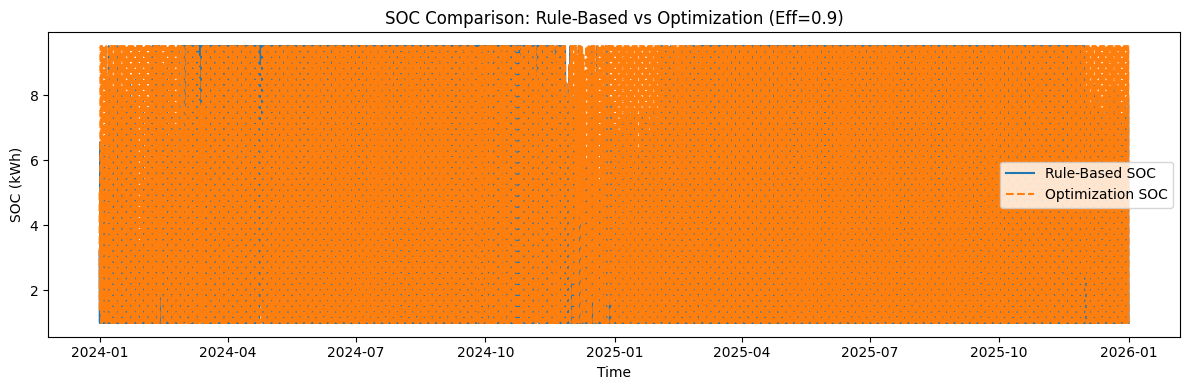

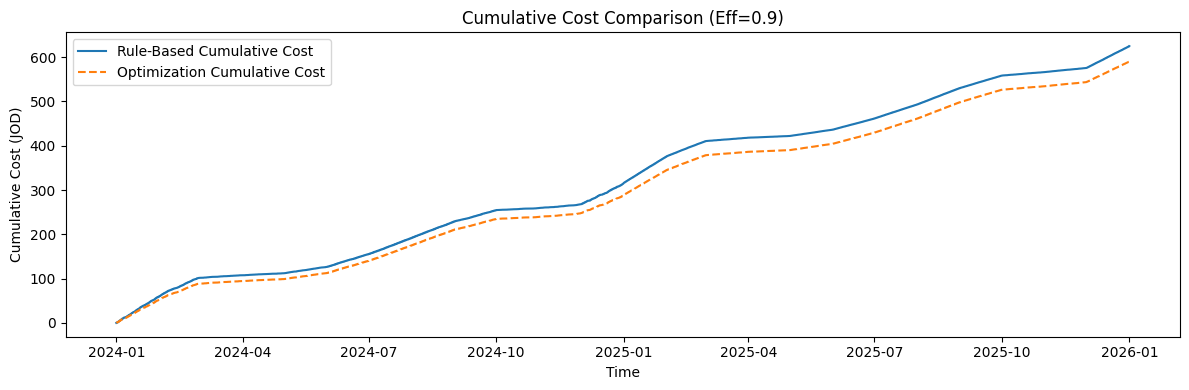

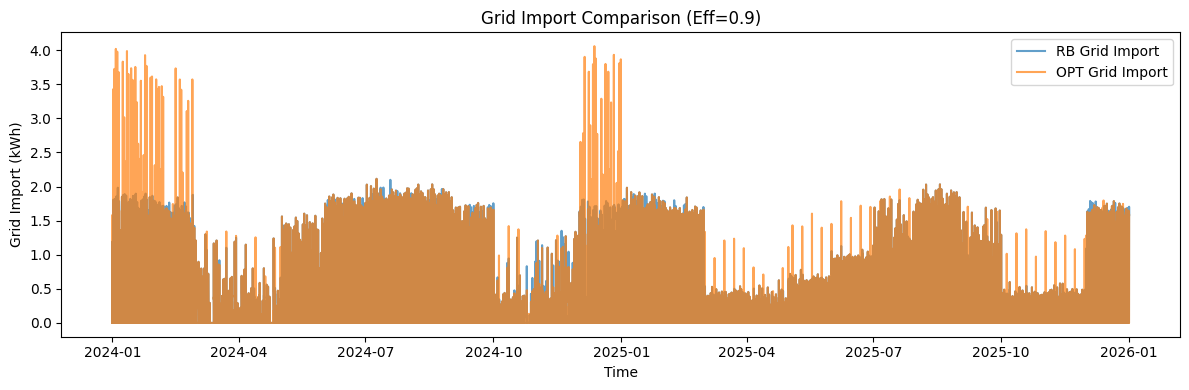

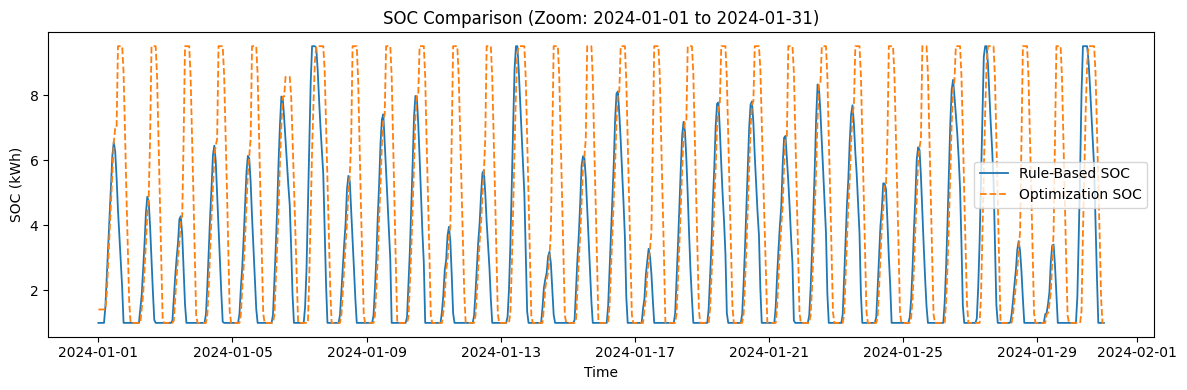

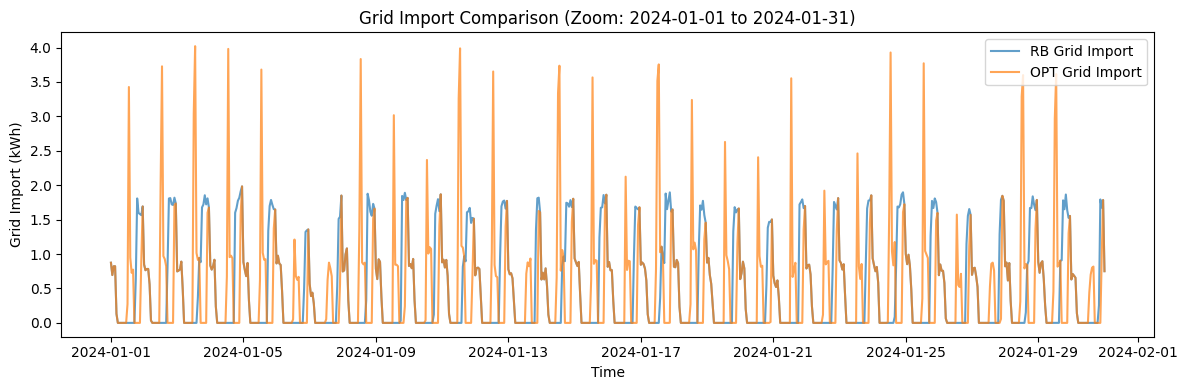

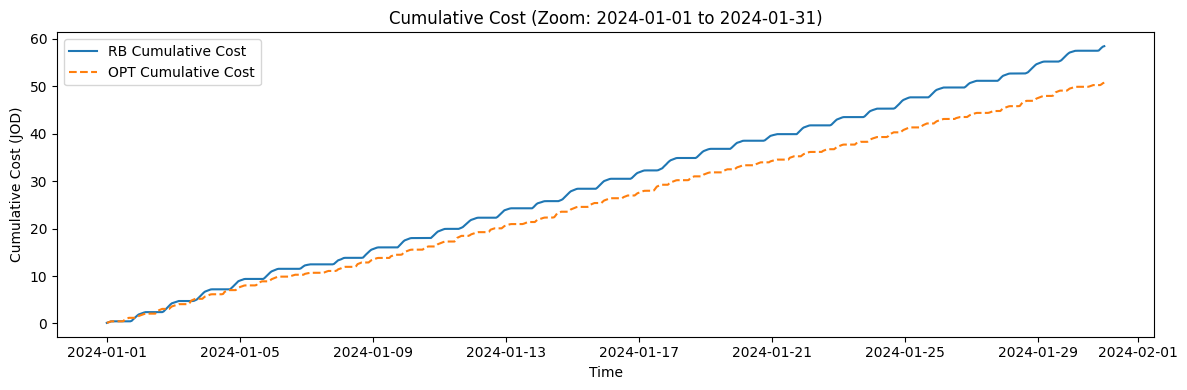

In [23]:
rb = rb_results.copy()

if opt_res is not None:
    opt = opt_res.copy()

   
    comp = {
        "metric": [
            "total_cost_JOD",
            "total_grid_import_kWh",
            "total_grid_export_kWh",
            "total_charged_kWh",
            "equivalent_full_cycles",
        ],
        "rule_based": [
            rb["cost_JOD"].sum(),
            rb["grid_import_kWh"].sum(),
            rb["grid_export_kWh"].sum(),
            rb["charge_kWh"].sum(),
            estimate_full_cycles_from_charged(rb["charge_kWh"], BATTERY_CAPACITY_KWH),
        ],
        "optimization": [
            opt["cost_JOD"].sum(),
            opt["grid_import_kWh"].sum(),
            opt["grid_export_kWh"].sum(),
            opt["charge_into_batt_kWh"].sum(),
            opt_summary["equivalent_full_cycles"],
        ],
    }

    comp_df = pd.DataFrame(comp)
    comp_path = os.path.join(OUT_DIR, "comparison_summary_eff09.csv")
    comp_df.to_csv(comp_path, index=False)
    print("\n=== Comparison summary (EFF = 0.9) ===")
    print(comp_df.to_string(index=False))
    print("\nComparison saved to:", comp_path)

    
    rb["timestamp"]  = pd.to_datetime(rb["timestamp"])
    opt["timestamp"] = pd.to_datetime(opt["timestamp"])

   
    plt.figure(figsize=(12,4))
    plt.plot(rb["timestamp"], rb["soc_kWh"], label="Rule-Based SOC")
    plt.plot(opt["timestamp"], opt["soc_kWh"], label="Optimization SOC", linestyle="--")
    plt.xlabel("Time")
    plt.ylabel("SOC (kWh)")
    plt.title("SOC Comparison: Rule-Based vs Optimization (Eff=0.9)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    
    plt.figure(figsize=(12,4))
    plt.plot(rb["timestamp"], rb["cumulative_cost_JOD"], label="Rule-Based Cumulative Cost")
    plt.plot(opt["timestamp"], opt["cumulative_cost_JOD"], label="Optimization Cumulative Cost", linestyle="--")
    plt.xlabel("Time")
    plt.ylabel("Cumulative Cost (JOD)")
    plt.title("Cumulative Cost Comparison (Eff=0.9)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    
    plt.figure(figsize=(12,4))
    plt.plot(rb["timestamp"], rb["grid_import_kWh"], label="RB Grid Import", alpha=0.7)
    plt.plot(opt["timestamp"], opt["grid_import_kWh"], label="OPT Grid Import", alpha=0.7)
    plt.xlabel("Time")
    plt.ylabel("Grid Import (kWh)")
    plt.title("Grid Import Comparison (Eff=0.9)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    
    start = "2024-01-01"
    end   = "2024-01-31"   

    mask_rb  = (rb["timestamp"] >= start) & (rb["timestamp"] <= end)
    mask_opt = (opt["timestamp"] >= start) & (opt["timestamp"] <= end)

    rb_slice  = rb.loc[mask_rb].copy()
    opt_slice = opt.loc[mask_opt].copy()

    
    plt.figure(figsize=(12,4))
    plt.plot(rb_slice["timestamp"], rb_slice["soc_kWh"],
             label="Rule-Based SOC", linewidth=1.3)
    plt.plot(opt_slice["timestamp"], opt_slice["soc_kWh"],
             label="Optimization SOC", linewidth=1.3, linestyle="--")
    plt.xlabel("Time")
    plt.ylabel("SOC (kWh)")
    plt.title(f"SOC Comparison (Zoom: {start} to {end})")
    plt.legend()
    plt.tight_layout()
    plt.show()

    
    plt.figure(figsize=(12,4))
    plt.plot(rb_slice["timestamp"], rb_slice["grid_import_kWh"],
             label="RB Grid Import", alpha=0.7)
    plt.plot(opt_slice["timestamp"], opt_slice["grid_import_kWh"],
             label="OPT Grid Import", alpha=0.7)
    plt.xlabel("Time")
    plt.ylabel("Grid Import (kWh)")
    plt.title(f"Grid Import Comparison (Zoom: {start} to {end})")
    plt.legend()
    plt.tight_layout()
    plt.show()

    
    rb_slice  = rb_slice.sort_values("timestamp")
    opt_slice = opt_slice.sort_values("timestamp")
    rb_slice["cum_cost"]  = rb_slice["cost_JOD"].cumsum()
    opt_slice["cum_cost"] = opt_slice["cost_JOD"].cumsum()

    plt.figure(figsize=(12,4))
    plt.plot(rb_slice["timestamp"], rb_slice["cum_cost"],
             label="RB Cumulative Cost")
    plt.plot(opt_slice["timestamp"], opt_slice["cum_cost"],
             label="OPT Cumulative Cost", linestyle="--")
    plt.xlabel("Time")
    plt.ylabel("Cumulative Cost (JOD)")
    plt.title(f"Cumulative Cost (Zoom: {start} to {end})")
    plt.legend()
    plt.tight_layout()
    plt.show()

else:
    print("Only Rule-Based results available. No optimization for comparison.")
